<a href="https://colab.research.google.com/github/Endoefa/ovo/blob/main/Tutorial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import the matplotlib package

* Can be used to creating static, animated, and interactive visualisations in Python
* plotting in a MATLAB style

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting

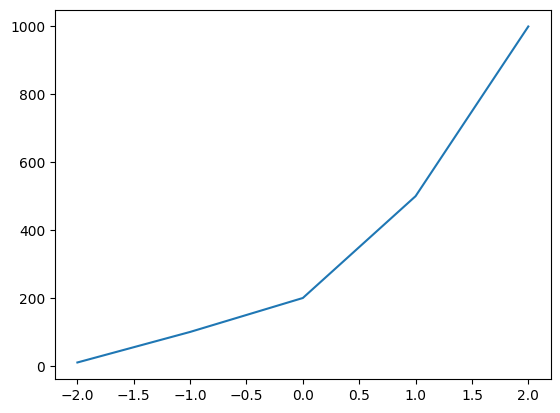

In [42]:
x = [-2, -1, 0, 1, 2]
y = [10, 100, 200, 500, 1000]
plt.plot(x, y)
plt.show()

* Add labels

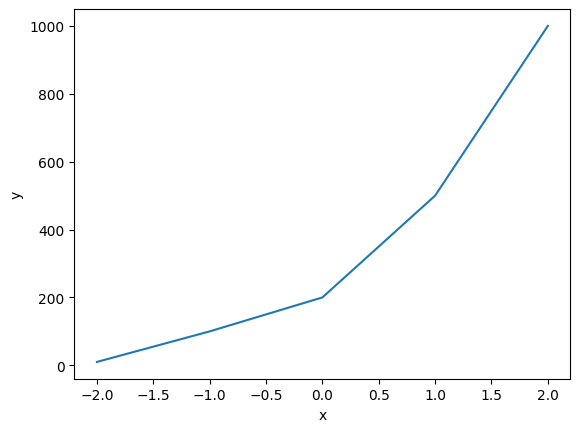

In [43]:
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

* Change colour/marker and specify axes

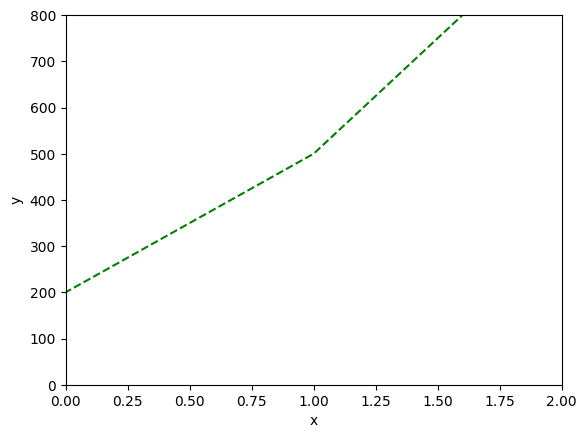

In [44]:
# 绘制曲线：绿色(g)虚线(--)，x为横坐标，y为纵坐标
plt.plot(x, y, 'g--')
# 设置x轴标签为x
plt.xlabel('x')
# 设置y轴标签为y
plt.ylabel('y')
# 设置坐标轴范围：x[0,2]，y[0,800]
plt.axis([0, 2, 0, 800])
# 显示绘制好的图像
plt.show()


* Scatter plot

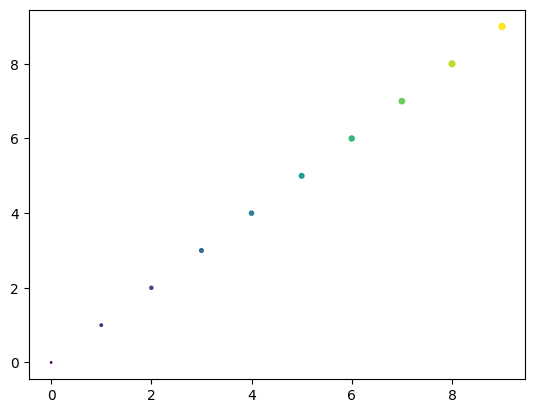

In [45]:
# 生成0到9的一维数组，作为散点图x坐标
x = np.arange(10)
# 生成0到9的一维数组，作为散点图y坐标
y = np.arange(10)
# 生成0到9的一维数组，用于控制点的颜色
c = np.arange(10)
# 生成从1开始，步长为2，小于20的数组，用于控制点的大小
s = np.arange(1, 20, 2)

# 绘制散点图：x,y确定点位置；c映射颜色；s映射点大小
plt.scatter(x=x, y=y, c=c, s=s)
#plt.scatter(x=x, y=y, c=c, s=s)
#- `c` = color（颜色）
#- `s` = size（散点面积）
# 展示图像
plt.show()


* Bar chart and subplots

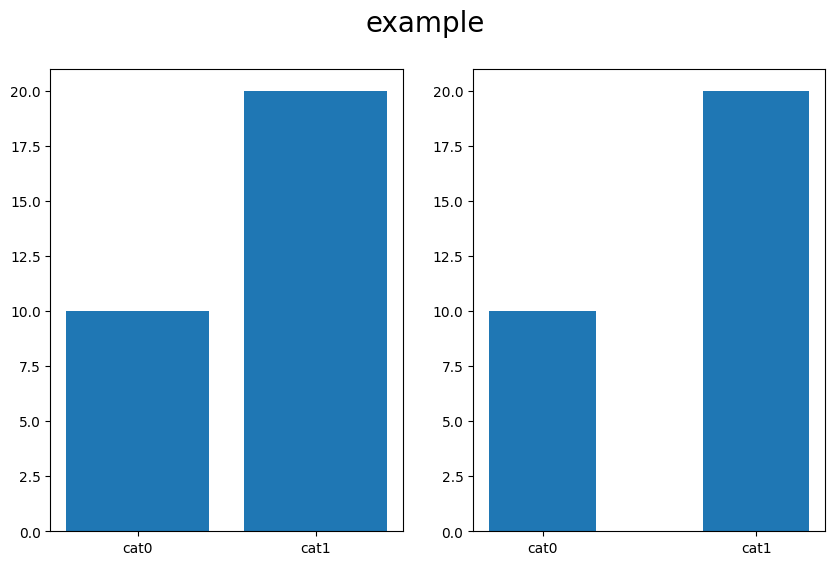

In [46]:
# 定义柱状图类别标签
cat = ['cat0', 'cat1']
# 定义每个类别对应的数值
num = [10, 20]

# 创建画布，设置画布大小：宽10，高6
plt.figure(figsize=(10, 6))

# 创建子图：1行2列，选中第1个子图
plt.subplot(121)   #plt.subplot(1, 2, 1)完整写法，逗号分隔  总行数，总列数，当前第几个子图
# 绘制柱状图，x为类别cat，高度为num，使用默认柱子宽度
plt.bar(cat, num)

plt.subplot(122)   # ✅ 创建并激活【右图】，现在画图目标 = 右子图
plt.bar(cat, num, width=0.5) # ✅ 在【当前激活的右子图】画柱状图

# 设置整张图的总标题（所有子图共用的标题），字体大小20
plt.suptitle('example', fontsize=20)

# 显示图像
plt.show()


# Read in an image


* using matplotlib

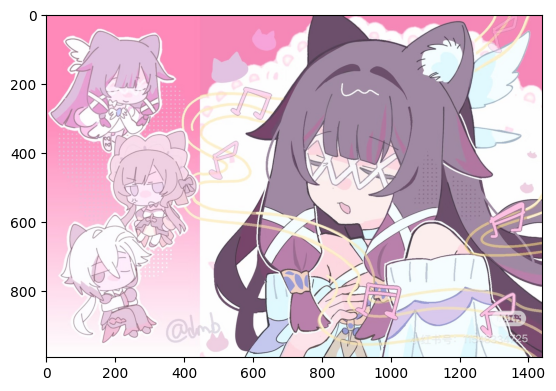

In [47]:
# 导入matplotlib的image模块，简写为mpimg，用于读取图像文件
import matplotlib.image as mpimg
# 读取指定路径下的图片，将图片转为像素数组存入变量img
img = mpimg.imread('/content/sample_data/sample_img.jpg')
# 在画布上显示读取到的图片数组。 **把图片像素数组 img 渲染绘制到当前激活的子图上**。
plt.imshow(img)
# 弹出窗口展示图像
plt.show()


* using OpenCV

In [48]:
# 导入opencv库，cv2是它的简写，用于图像处理
import cv2
# 读取指定路径的图片，得到图片像素数组（OpenCV默认BGR通道顺序）
img = cv2.imread('/content/sample_data/sample_img.jpg')
# cv2.imshow('image', img)
# 注释掉：原生cv2.imshow需要本地窗口，在Google Colab网页环境不能直接使用


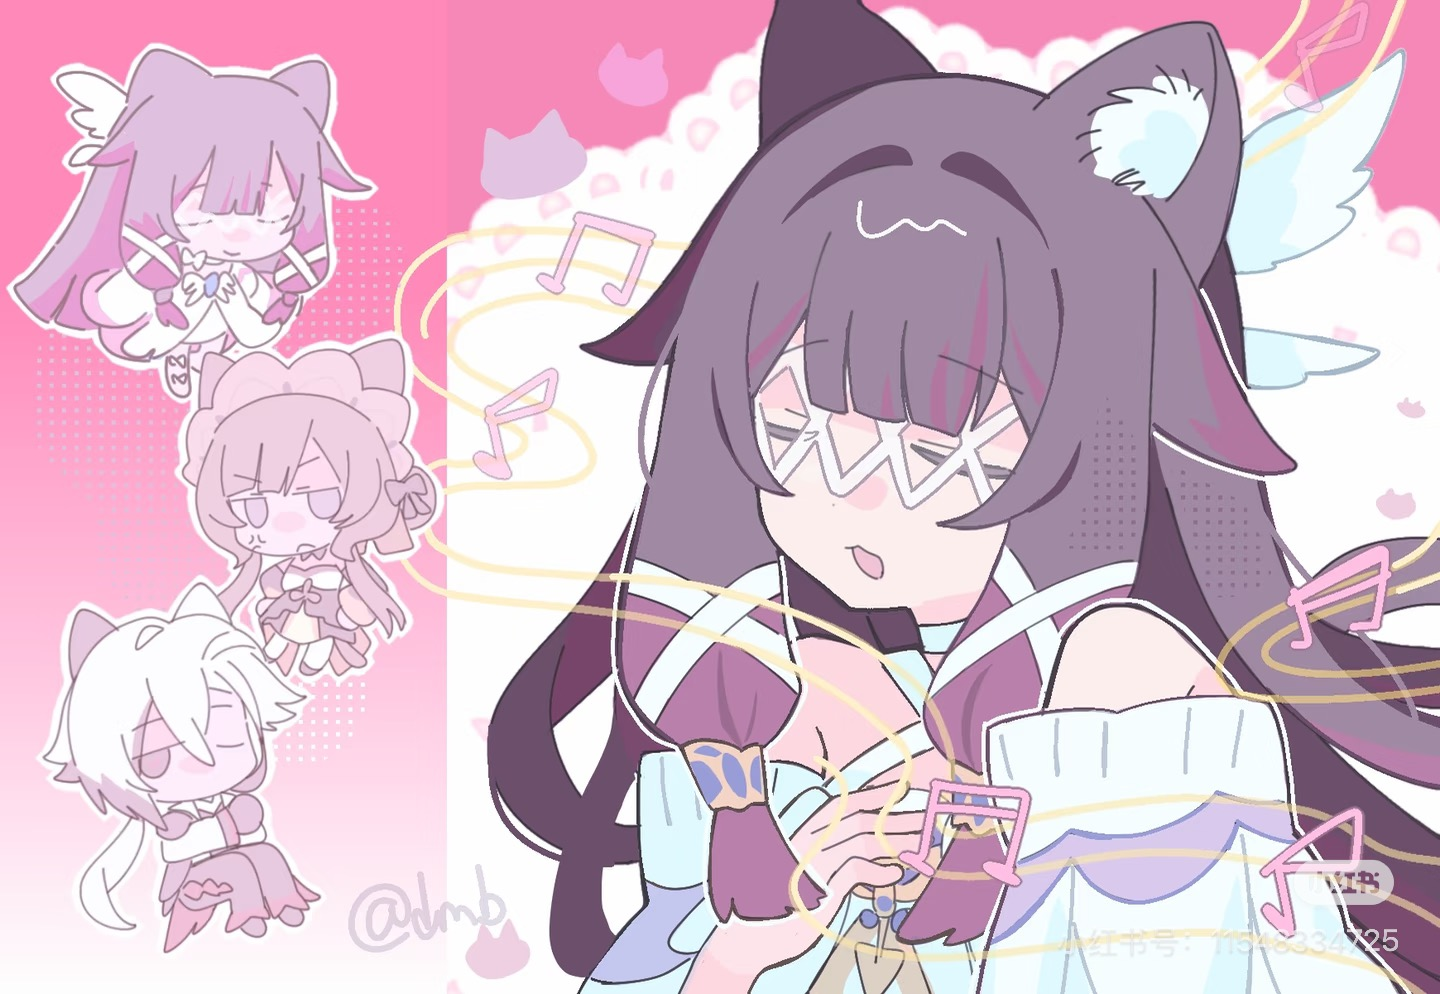

In [49]:
# 从colab补丁包导入适配colab环境的cv2图像显示函数
from google.colab.patches import cv2_imshow
# 在Colab网页中直接显示opencv读取的图片
cv2_imshow(img)

两者**都可以读取图片，转成numpy像素数组**，但是设计目标不一样：
- `matplotlib.image`：**画图、可视化**配套，读出来是**RGB**，和`plt.imshow`天生适配，适合做图表、在画布上叠加图片。
- `cv2(OpenCV)`：**计算机视觉图像处理**（检测、滤波、裁剪、特征识别），读出来默认**BGR**，专门用来做图像算法。

---

## 1. 核心区别对照表
|项目|matplotlib.image (mpimg)|cv2.imread() (OpenCV)|
|---|---|---|
|所属库|matplotlib（绘图库）|OpenCV（计算机视觉库）|
|通道顺序|**RGB（红-绿-蓝）**|**BGR（蓝-绿-红）**|
|主要用途|读图，给`plt.imshow`显示，画图排版|图像算法：模糊、边缘检测、人脸检测、裁剪、变换|
|读取返回值|numpy数组 `(高度,宽度,3)`，RGB|numpy数组 `(高度,宽度,3)`，BGR|
|在Colab显示|直接`plt.imshow(img)`即可|原生`cv2.imshow`不能用，要用`cv2_imshow()`|

> ⚠️ 坑：**cv2读的图直接丢进plt.imshow，颜色会反过来（偏蓝）**，因为通道顺序颠倒。
> 解决：`img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`

## 2. 为什么课程里要同时讲这两个？
这是机器学习/计算机视觉入门的经典教学安排，两个场景都要会：
1. **matplotlib.image**：用来**查看图片、画子图、加坐标轴、标题**。
    - 适合：把多张图片并排对比、在图上画框/文字、做可视化汇报。
    - 它是**绘图工具**，不是图像处理工具。
2. **OpenCV(cv2)**：用来**处理图片**（修改像素、滤波、识别）。
    - 适合：写图像算法，图片预处理（深度学习数据集最常用）。
    - 它是**图像处理工具**。

👉 教学逻辑：
> 你可以用`cv2`读取+处理图片，然后交给matplotlib做可视化展示；
> 或者简单图片直接mpimg读取，plt直接显示。
> 两个库各司其职，项目里经常**搭配一起用**，所以入门课同时介绍。

## 3. 什么时候选哪个？
- 只想**展示图片、画子图、加标签** → 用`matplotlib.image + plt.imshow`
- 要**做图像处理（模糊、裁剪、边缘检测）** → 用`cv2`

注：虽然 cv2 可以独立显示，但很多时候：

1. 想**并排画多张图片做对比子图**（1 行 2 列这种），`cv2_imshow`做子图很麻烦，这时候就把 cv2 图片转 RGB，交给 matplotlib 的 subplot 来排版。
2. 需要在图片上叠加文字、方框、坐标轴，matplotlib 绘图功能更强。



* Try to fix this problem yourself

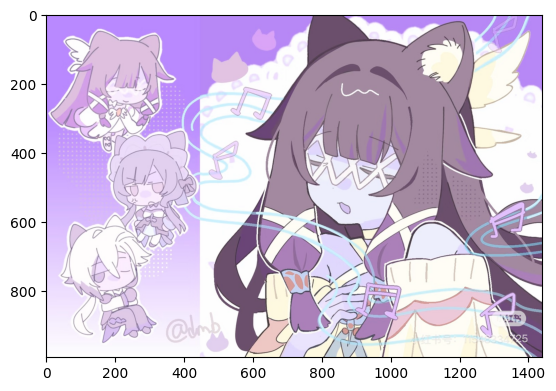

In [50]:
plt.imshow(img) # note that the colour is not displayed correctly, why?
# OpenCV uses BGR instead of RGB!
# How to fix it?

* using the Python Imaging Library (PIL)

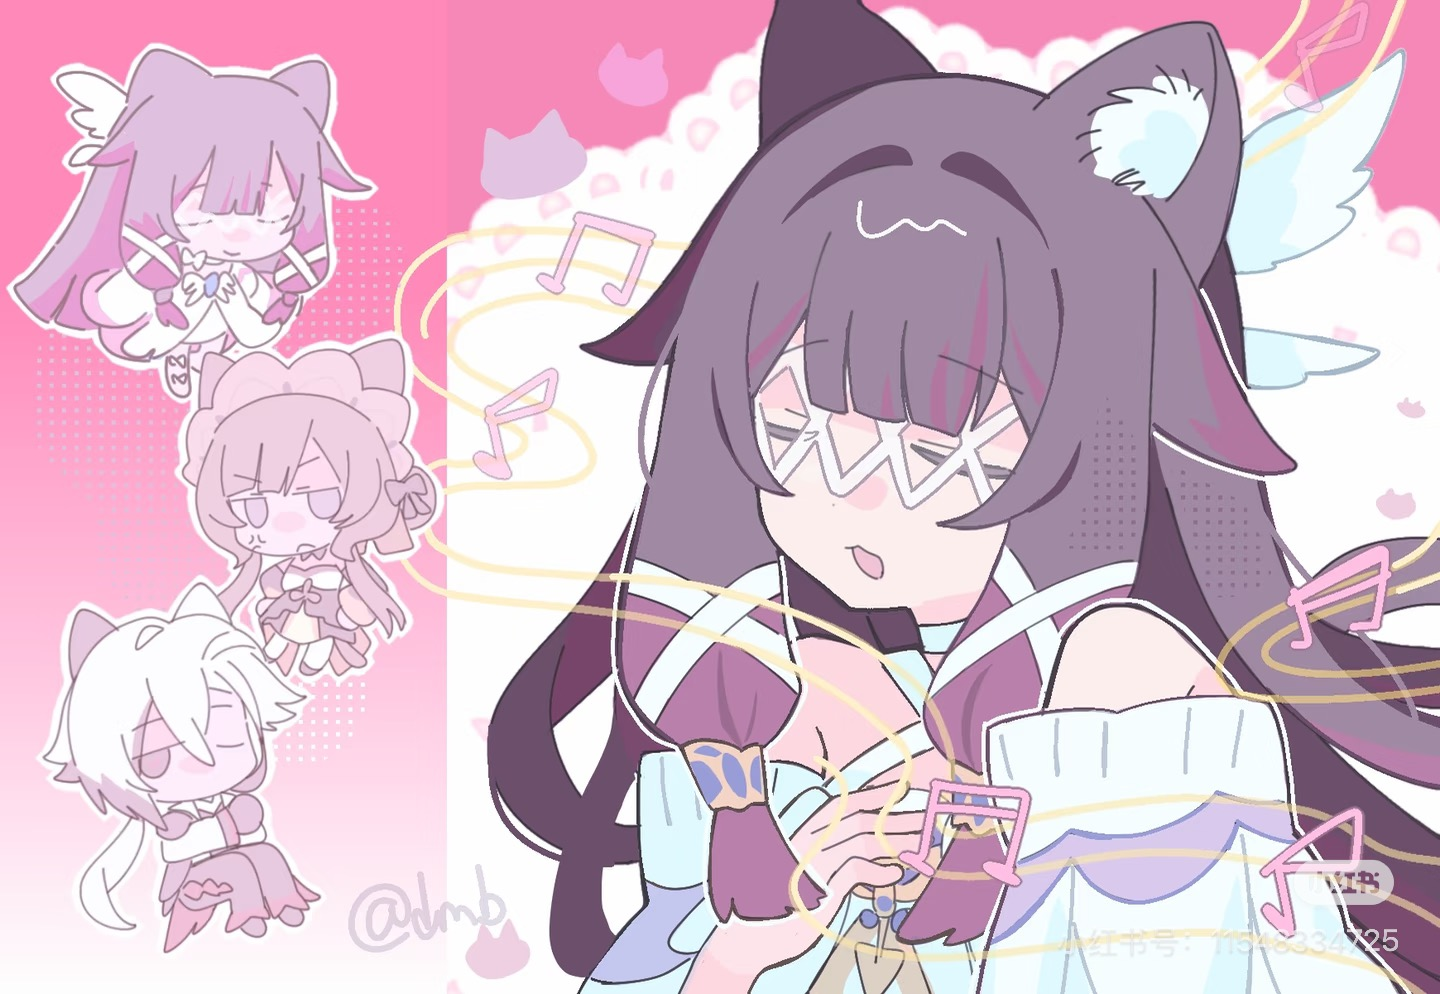

In [51]:
# 从PIL库导入Image类，PIL是Python经典图像处理库Pillow
from PIL import Image
# 从IPython库导入display函数，用于在Jupyter/Colab网页单元格里直接展示对象
from IPython.display import display # to display images

# 使用PIL打开指定路径的图片，得到PIL图像对象
pil_im = Image.open('/content/sample_data/sample_img.jpg')
# 在网页中显示这个PIL图片对象
display(pil_im)


PIL（Pillow）是**另一个读图方案**，和前面两个对比：
1. `mpimg`：读成numpy数组，适配matplotlib绘图
2. `cv2`：读成numpy数组（BGR），专门做计算机视觉算法
3. **PIL Image**：得到的是**PIL图像对象**，不是numpy数组；直接用`display()`在Colab/Jupyter展示，**不用matplotlib**

> 如果你后续要把PIL图片转成numpy数组，可以写：
> ```python
> import numpy as np
> img_array = np.array(pil_im)
> ```
> 转完之后就是RGB数组，可以丢进`plt.imshow()`

### 三个读图工具一句话区分
- matplotlib.image：读图给plt画图
- cv2：读图做图像算法
- PIL Image：轻量打开图片，IPython的display直接渲染预览




* cropping

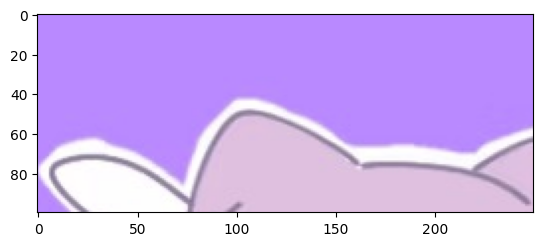

In [52]:
img_cropped = img[0:100, 50:300, :] #img[高度范围, 宽度范围, 通道]
plt.imshow(img_cropped)

* RGB to Grey (recall lecture 2)

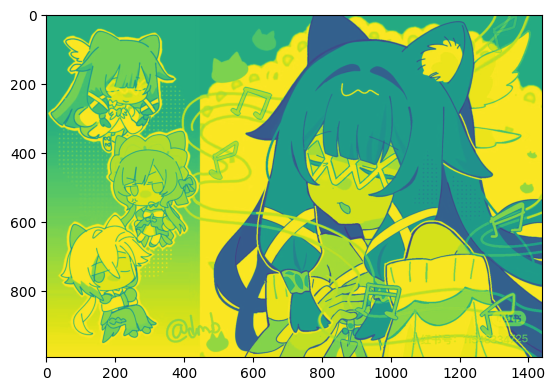

In [53]:
# 加权方式将RGB彩色图像转为灰度图像
# :,: 代表所有像素行和列；0=R通道，1=G通道，2=B通道
img_grey = img[:, :, 0]*0.2989 + img[:, :, 1]*0.5870 + img[:, :, 2]*0.1140

# 把浮点数像素转换成图像标准uint8（0~255整数）
img_grey = img_grey.astype(np.uint8)

# 显示灰度图，cmap='gray'指定灰度色彩映射，否则会出现黄绿伪彩色
plt.imshow(img_grey, cmap='gray')
plt.show()


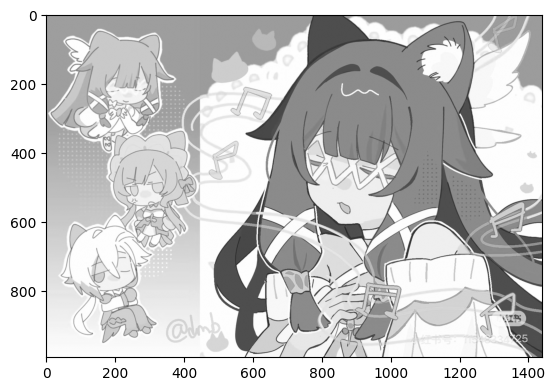

In [54]:
plt.imshow(img_grey, cmap='gray')  # using the gray colour space

# Explore other methods for image cropping and colour-greyscale conversion enabled by different python packages yourself